# 06 — Advanced Models (Week 7)

**Goal:** beat the Week 6 Random Forest (test R² **0.7465**) with **gradient boosting**, and do the
hyperparameter tuning *honestly* — i.e. without ever looking at the test month.

Steps:
1. **Load** the Week 6 enriched dataset and rebuild the leakage-safe split.
2. **Train** XGBoost and LightGBM out of the box.
3. **Tune** both with a small grid + early stopping on a **validation month** carved out of the
   training window (never the test month).
4. **Try a log-price variant** — house prices are right-skewed, so modelling `log(price)` is the
   standard fix. Does it help?
5. **Re-sweep the training window `X`** for the winning model — Week 4 tuned `X` for a *linear* model,
   boosting may want a different window.
6. **Save** the winning model as a self-contained bundle for Weeks 8-9.

> **Tuning protocol.** `train` = the `X` months before the test month. Inside that window the **last
> month is held out as validation** and used for early stopping / model selection. The winning config is
> then refit on the *whole* window and scored once on the test month. The test month influences nothing.

In [1]:
import json
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

pd.set_option("display.max_columns", 120)
plt.rcParams["figure.figsize"] = (8, 5)

# LightGBM 4.7 renamed fit(eval_set=...) -> fit(eval_X=, eval_y=); we keep the portable spelling
# and silence the one-line deprecation notice so the tuning log below stays readable.
warnings.filterwarnings("ignore", message=".*eval_set.*")

print("xgboost", xgb.__version__, "| lightgbm", lgb.__version__)

xgboost 3.3.0 | lightgbm 4.7.0


## 1. Load the Week 6 features and rebuild the split

Two changes from Week 6, both from its own findings:

- **`FireplacesTotal` / `FireplacesTotal_missing` / `has_fireplace` are dropped** — the source column is
  100% null in this extract, and Week 6 measured its Random Forest importance at exactly 0.0000.
- The split function is otherwise identical (train-only medians, frequency encoding, district price
  encoding, scaler), and it now also returns the fitted encoders so we can ship them in the model bundle.

In [2]:
FEATURES_PATH = "data/processed/sold_features.csv"

d = pd.read_csv(FEATURES_PATH, low_memory=False)
d["CloseDate"] = pd.to_datetime(d["CloseDate"], errors="coerce")
d["month_key"] = d["CloseDate"].dt.to_period("M")

TARGET = "ClosePrice"
DEAD_COLS = ["FireplacesTotal", "FireplacesTotal_missing", "has_fireplace"]   # 100% null in this extract

BASE_NUMERIC = ["LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "LotSizeSquareFeet",
                "YearBuilt", "GarageSpaces", "Stories", "FireplacesTotal", "Latitude", "Longitude"]
ENGINEERED_NUMERIC = ["bed_bath_ratio", "living_area_per_bed", "lot_to_living_ratio", "total_rooms",
                      "property_age", "is_new_build", "has_garage", "has_fireplace",
                      "close_month_sin", "close_month_cos"]
SCHOOL_NUMERIC = ["district_enroll", "district_sed_pct", "district_el_pct", "is_unified"]
MISSING_FLAGS = [c for c in d.columns if c.endswith("_missing")]
CATEGORICAL = ["CountyOrParish", "City", "PostalCode", "SchoolDistrict", "HighSchoolDistrict"]
ENCODED = ["district_ppsf_enc", "district_price_enc"]

NUMERIC = [c for c in BASE_NUMERIC + MISSING_FLAGS + ENGINEERED_NUMERIC + SCHOOL_NUMERIC
           if c not in DEAD_COLS]
MIN_DISTRICT_N = 20

months = sorted(d["month_key"].dropna().unique())
print(f"Loaded {len(d):,} rows x {d.shape[1]} cols | {len(months)} months "
      f"({months[0]} .. {months[-1]})")
print(f"Dropped as 100% null: {DEAD_COLS}")
print(f"Feature count: {len(NUMERIC)} numeric + {len(CATEGORICAL)} freq-encoded + {len(ENCODED)} district-encoded"
      f" = {len(NUMERIC) + len(CATEGORICAL) + len(ENCODED)}")

Loaded 319,311 rows x 37 cols | 29 months (2024-01 .. 2026-05)
Dropped as 100% null: ['FireplacesTotal', 'FireplacesTotal_missing', 'has_fireplace']
Feature count: 24 numeric + 5 freq-encoded + 2 district-encoded = 31


In [3]:
FEATURE_COLS = NUMERIC + [f"{c}_freq" for c in CATEGORICAL] + ENCODED


def fit_encoders(train):
    '''Everything that has to be learned from the training rows only.'''
    enc = {"medians": train[NUMERIC].median().to_dict()}
    enc["freq"] = {c: train[c].value_counts(normalize=True).to_dict() for c in CATEGORICAL}

    ppsf = train[TARGET] / train["LivingArea"].replace(0, np.nan)
    stats = (pd.DataFrame({"district": train["SchoolDistrict"], "ppsf": ppsf, "price": train[TARGET]})
               .groupby("district")
               .agg(n=("price", "size"), ppsf=("ppsf", "median"), price=("price", "median")))
    stats = stats[stats["n"] >= MIN_DISTRICT_N]
    enc["district_ppsf"] = stats["ppsf"].to_dict()
    enc["district_price"] = stats["price"].to_dict()
    enc["global_ppsf"] = float(ppsf.median())
    enc["global_price"] = float(train[TARGET].median())
    return enc


def apply_encoders(frame, enc):
    '''Turn raw rows into the model matrix using already-fitted encoders.'''
    out = frame.copy()
    out[NUMERIC] = out[NUMERIC].fillna(pd.Series(enc["medians"])).fillna(0.0)
    for c in CATEGORICAL:
        out[f"{c}_freq"] = out[c].map(enc["freq"][c]).fillna(0.0)
    out["district_ppsf_enc"] = out["SchoolDistrict"].map(enc["district_ppsf"]).fillna(enc["global_ppsf"])
    out["district_price_enc"] = out["SchoolDistrict"].map(enc["district_price"]).fillna(enc["global_price"])
    return out[FEATURE_COLS]


def build_split(X, val_months=1, scale=False):
    '''test = most recent month; train = X months before it; the last `val_months` of the
    training window are held out for tuning / early stopping.'''
    test_month = months[-1]
    train_months = months[-(X + 1):-1]
    if len(train_months) < X:
        raise ValueError(f"Only {len(months) - 1} months before the test month; X={X} too large.")

    train_all = d[d.month_key.isin(train_months)]
    test = d[d.month_key == test_month]

    enc = fit_encoders(train_all)                 # encoders for the final fit: whole window
    out = {"enc": enc, "feature_cols": FEATURE_COLS,
           "X_train": apply_encoders(train_all, enc), "y_train": train_all[TARGET],
           "X_test": apply_encoders(test, enc), "y_test": test[TARGET],
           "test_month": str(test_month), "train_months": [str(m) for m in train_months]}

    if val_months:                                # tuning view: fit encoders on the sub-window only
        fit_months, v_months = train_months[:-val_months], train_months[-val_months:]
        sub, val = d[d.month_key.isin(fit_months)], d[d.month_key.isin(v_months)]
        enc_sub = fit_encoders(sub)
        out.update({"X_fit": apply_encoders(sub, enc_sub), "y_fit": sub[TARGET],
                    "X_val": apply_encoders(val, enc_sub), "y_val": val[TARGET],
                    "val_months": [str(m) for m in v_months]})

    if scale:
        scaler = StandardScaler().fit(out["X_train"])
        out["scaler"] = scaler
    return out


def evaluate(y_true, y_pred):
    return {"R2": r2_score(y_true, y_pred),
            "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
            "MAE": mean_absolute_error(y_true, y_pred)}


BEST_X = 13
split = build_split(BEST_X)
print("test month  :", split["test_month"])
print("train window:", f"{BEST_X} months ({split['train_months'][0]} .. {split['train_months'][-1]})")
print("validation  :", split["val_months"], "(held out of the tuning fit)")
print(f"rows -> fit {len(split['y_fit']):,} | val {len(split['y_val']):,} | "
      f"train(all) {len(split['y_train']):,} | test {len(split['y_test']):,}")

test month  : 2026-05
train window: 13 months (2025-04 .. 2026-04)
validation  : ['2026-04'] (held out of the tuning fit)
rows -> fit 129,300 | val 11,977 | train(all) 141,277 | test 11,976


## 2. Out-of-the-box gradient boosting

First pass with sensible defaults, no tuning — this tells us how much of the gain is "just boosting"
versus tuning. Both use histogram-based tree building, which is what makes them fast on 140k rows.

In [4]:
X_tr, y_tr = split["X_train"], split["y_train"]
X_te, y_te = split["X_test"], split["y_test"]

results = {}
timings = {}

# --- Random Forest: the Week 6 champion, retrained here so the comparison is like-for-like ---
t0 = time.time()
rf = RandomForestRegressor(n_estimators=200, min_samples_leaf=5, n_jobs=-1, random_state=42)
rf.fit(X_tr, y_tr)
timings["Random Forest (Wk6)"] = time.time() - t0
results["Random Forest (Wk6)"] = {**evaluate(y_te, rf.predict(X_te)),
                                  "Train R2": r2_score(y_tr, rf.predict(X_tr))}

# --- XGBoost, defaults ---
t0 = time.time()
xgb_default = xgb.XGBRegressor(n_estimators=400, learning_rate=0.1, max_depth=6,
                               tree_method="hist", n_jobs=-1, random_state=42)
xgb_default.fit(X_tr, y_tr)
timings["XGBoost (default)"] = time.time() - t0
results["XGBoost (default)"] = {**evaluate(y_te, xgb_default.predict(X_te)),
                                "Train R2": r2_score(y_tr, xgb_default.predict(X_tr))}

# --- LightGBM, defaults ---
t0 = time.time()
lgb_default = lgb.LGBMRegressor(n_estimators=400, learning_rate=0.1, num_leaves=63,
                                n_jobs=-1, random_state=42, verbose=-1)
lgb_default.fit(X_tr, y_tr)
timings["LightGBM (default)"] = time.time() - t0
results["LightGBM (default)"] = {**evaluate(y_te, lgb_default.predict(X_te)),
                                 "Train R2": r2_score(y_tr, lgb_default.predict(X_tr))}

first_pass = pd.DataFrame(results).T[["Train R2", "R2", "RMSE", "MAE"]].rename(columns={"R2": "Test R2"})
first_pass["fit seconds"] = pd.Series(timings)
first_pass.round({"Train R2": 4, "Test R2": 4, "RMSE": 0, "MAE": 0, "fit seconds": 1})

,Train R2,Test R2,RMSE,MAE,fit seconds
Random Forest (Wk6),0.9029,0.7466,708006.0,198286.0,40.0
XGBoost (default),0.9492,0.7593,690027.0,200772.0,1.6
LightGBM (default),0.9570,0.7486,705184.0,200426.0,3.3


## 3. Light hyperparameter tuning

A small, deliberately readable grid. Every candidate is fit on the **fit** months and early-stopped on
the **validation** month; the score that ranks candidates is validation R², so the test month stays
untouched.

- **XGBoost:** `max_depth` × `learning_rate` × `min_child_weight`, `subsample`/`colsample` fixed at 0.8
- **LightGBM:** `num_leaves` × `learning_rate` × `min_child_samples`

`n_estimators` is not tuned by hand — early stopping picks it per candidate.

In [5]:
X_fit, y_fit = split["X_fit"], split["y_fit"]
X_val, y_val = split["X_val"], split["y_val"]

xgb_grid = [{"max_depth": md, "learning_rate": lr, "min_child_weight": mcw}
            for md in (6, 8, 10) for lr in (0.05, 0.1) for mcw in (1, 10)]

xgb_trials = []
for i, params in enumerate(xgb_grid, 1):
    m = xgb.XGBRegressor(n_estimators=3000, subsample=0.8, colsample_bytree=0.8,
                         tree_method="hist", n_jobs=-1, random_state=42,
                         early_stopping_rounds=50, eval_metric="rmse", **params)
    m.fit(X_fit, y_fit, eval_set=[(X_val, y_val)], verbose=False)
    val_r2 = r2_score(y_val, m.predict(X_val))
    xgb_trials.append({**params, "best_n_estimators": m.best_iteration + 1, "val R2": val_r2})
    print(f"  [{i:2d}/{len(xgb_grid)}] depth={params['max_depth']:>2} lr={params['learning_rate']:.2f} "
          f"mcw={params['min_child_weight']:>2} -> rounds={m.best_iteration + 1:>4}  val R2={val_r2:.4f}")

xgb_tuning = pd.DataFrame(xgb_trials).sort_values("val R2", ascending=False)
print("\nBest XGBoost config on validation:")
print(xgb_tuning.head(3).round(4).to_string(index=False))

  [ 1/12] depth= 6 lr=0.05 mcw= 1 -> rounds=1112  val R2=0.7943


  [ 2/12] depth= 6 lr=0.05 mcw=10 -> rounds= 905  val R2=0.7989


  [ 3/12] depth= 6 lr=0.10 mcw= 1 -> rounds= 411  val R2=0.7920


  [ 4/12] depth= 6 lr=0.10 mcw=10 -> rounds= 538  val R2=0.7998


  [ 5/12] depth= 8 lr=0.05 mcw= 1 -> rounds= 659  val R2=0.7996


...

  [ 8/12] depth= 8 lr=0.10 mcw=10 -> rounds= 454  val R2=0.7994


  [ 9/12] depth=10 lr=0.05 mcw= 1 -> rounds= 921  val R2=0.7969


  [10/12] depth=10 lr=0.05 mcw=10 -> rounds=1194  val R2=0.7974


  [11/12] depth=10 lr=0.10 mcw= 1 -> rounds= 409  val R2=0.7926


  [12/12] depth=10 lr=0.10 mcw=10 -> rounds= 503  val R2=0.8027

Best XGBoost config on validation:
 max_depth  learning_rate  min_child_weight  best_n_estimators  val R2
        10           0.10                10                503  0.8027
         6           0.10                10                538  0.7998
         8           0.05                10                872  0.7997


In [6]:
lgb_grid = [{"num_leaves": nl, "learning_rate": lr, "min_child_samples": mcs}
            for nl in (63, 127, 255) for lr in (0.05, 0.1) for mcs in (20, 50)]

lgb_trials = []
for i, params in enumerate(lgb_grid, 1):
    m = lgb.LGBMRegressor(n_estimators=3000, subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
                          n_jobs=-1, random_state=42, verbose=-1, **params)
    m.fit(X_fit, y_fit, eval_set=[(X_val, y_val)], eval_metric="rmse",
          callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])
    val_r2 = r2_score(y_val, m.predict(X_val))
    lgb_trials.append({**params, "best_n_estimators": m.best_iteration_, "val R2": val_r2})
    print(f"  [{i:2d}/{len(lgb_grid)}] leaves={params['num_leaves']:>3} lr={params['learning_rate']:.2f} "
          f"mcs={params['min_child_samples']:>2} -> rounds={m.best_iteration_:>4}  val R2={val_r2:.4f}")

lgb_tuning = pd.DataFrame(lgb_trials).sort_values("val R2", ascending=False)
print("\nBest LightGBM config on validation:")
print(lgb_tuning.head(3).round(4).to_string(index=False))

  [ 1/12] leaves= 63 lr=0.05 mcs=20 -> rounds= 872  val R2=0.8071


  [ 2/12] leaves= 63 lr=0.05 mcs=50 -> rounds= 492  val R2=0.7921


  [ 3/12] leaves= 63 lr=0.10 mcs=20 -> rounds= 475  val R2=0.8040


  [ 4/12] leaves= 63 lr=0.10 mcs=50 -> rounds= 447  val R2=0.7960


  [ 5/12] leaves=127 lr=0.05 mcs=20 -> rounds= 758  val R2=0.8014


...

  [ 8/12] leaves=127 lr=0.10 mcs=50 -> rounds= 482  val R2=0.7889


  [ 9/12] leaves=255 lr=0.05 mcs=20 -> rounds= 526  val R2=0.8011


  [10/12] leaves=255 lr=0.05 mcs=50 -> rounds= 492  val R2=0.7856


  [11/12] leaves=255 lr=0.10 mcs=20 -> rounds= 164  val R2=0.7970


  [12/12] leaves=255 lr=0.10 mcs=50 -> rounds= 177  val R2=0.7771

Best LightGBM config on validation:
 num_leaves  learning_rate  min_child_samples  best_n_estimators  val R2
         63           0.05                 20                872  0.8071
         63           0.10                 20                475  0.8040
        127           0.05                 20                758  0.8014


## 4. Refit the winners on the full training window, score once on the test month

Early stopping chose `n_estimators` against 1 month of validation data; refitting on the full window
(≈8% more rows) means slightly more data per round, so we scale the round count up by the same ratio.

In [7]:
scale_up = len(y_tr) / len(y_fit)
print(f"fit rows {len(y_fit):,} -> full-window rows {len(y_tr):,} (x{scale_up:.2f} rounds)")

best_xgb_cfg = xgb_tuning.iloc[0].to_dict()
best_lgb_cfg = lgb_tuning.iloc[0].to_dict()

xgb_best = xgb.XGBRegressor(
    n_estimators=int(best_xgb_cfg["best_n_estimators"] * scale_up),
    max_depth=int(best_xgb_cfg["max_depth"]), learning_rate=best_xgb_cfg["learning_rate"],
    min_child_weight=int(best_xgb_cfg["min_child_weight"]),
    subsample=0.8, colsample_bytree=0.8, tree_method="hist", n_jobs=-1, random_state=42)
t0 = time.time(); xgb_best.fit(X_tr, y_tr); timings["XGBoost (tuned)"] = time.time() - t0
results["XGBoost (tuned)"] = {**evaluate(y_te, xgb_best.predict(X_te)),
                              "Train R2": r2_score(y_tr, xgb_best.predict(X_tr))}

lgb_best = lgb.LGBMRegressor(
    n_estimators=int(best_lgb_cfg["best_n_estimators"] * scale_up),
    num_leaves=int(best_lgb_cfg["num_leaves"]), learning_rate=best_lgb_cfg["learning_rate"],
    min_child_samples=int(best_lgb_cfg["min_child_samples"]),
    subsample=0.8, subsample_freq=1, colsample_bytree=0.8, importance_type="gain",
    n_jobs=-1, random_state=42, verbose=-1)
t0 = time.time(); lgb_best.fit(X_tr, y_tr); timings["LightGBM (tuned)"] = time.time() - t0
results["LightGBM (tuned)"] = {**evaluate(y_te, lgb_best.predict(X_te)),
                               "Train R2": r2_score(y_tr, lgb_best.predict(X_tr))}

for name in ["XGBoost (tuned)", "LightGBM (tuned)"]:
    r = results[name]
    print(f"{name:20s} test R2={r['R2']:.4f}  RMSE=${r['RMSE']:,.0f}  MAE=${r['MAE']:,.0f}")

fit rows 129,300 -> full-window rows 141,277 (x1.09 rounds)


XGBoost (tuned)      test R2=0.7552  RMSE=$695,949  MAE=$193,892
LightGBM (tuned)     test R2=0.7504  RMSE=$702,733  MAE=$198,322


## 5. Does modelling `log(price)` help?

`ClosePrice` is strongly right-skewed (a \$40M Malibu sale sits in the same column as a \$200k Barstow
sale). Squared-error training on the raw scale therefore spends most of its capacity on the few most
expensive homes. Training on `log(price)` and exponentiating back optimises *relative* error instead —
which is also what the Week 8 percentage metrics will measure.

The comparison below is on the same test month, so it is a fair read on both scales.

In [8]:
best_family = "XGBoost" if results["XGBoost (tuned)"]["R2"] >= results["LightGBM (tuned)"]["R2"] else "LightGBM"
print("Best family so far:", best_family)


def make_best(**over):
    if best_family == "XGBoost":
        cfg = dict(n_estimators=int(best_xgb_cfg["best_n_estimators"] * scale_up),
                   max_depth=int(best_xgb_cfg["max_depth"]),
                   learning_rate=best_xgb_cfg["learning_rate"],
                   min_child_weight=int(best_xgb_cfg["min_child_weight"]),
                   subsample=0.8, colsample_bytree=0.8, tree_method="hist",
                   n_jobs=-1, random_state=42)
        return xgb.XGBRegressor(**{**cfg, **over})
    cfg = dict(n_estimators=int(best_lgb_cfg["best_n_estimators"] * scale_up),
               num_leaves=int(best_lgb_cfg["num_leaves"]),
               learning_rate=best_lgb_cfg["learning_rate"],
               min_child_samples=int(best_lgb_cfg["min_child_samples"]),
               subsample=0.8, subsample_freq=1, colsample_bytree=0.8, importance_type="gain",
               n_jobs=-1, random_state=42, verbose=-1)
    return lgb.LGBMRegressor(**{**cfg, **over})


log_model = make_best()
t0 = time.time(); log_model.fit(X_tr, np.log(y_tr)); timings[f"{best_family} (log target)"] = time.time() - t0
pred_log = np.exp(log_model.predict(X_te))
results[f"{best_family} (log target)"] = {**evaluate(y_te, pred_log),
                                          "Train R2": r2_score(y_tr, np.exp(log_model.predict(X_tr)))}

raw = results[f"{best_family} (tuned)"]
log = results[f"{best_family} (log target)"]
print(f"raw target : R2={raw['R2']:.4f}  RMSE=${raw['RMSE']:,.0f}  MAE=${raw['MAE']:,.0f}")
print(f"log target : R2={log['R2']:.4f}  RMSE=${log['RMSE']:,.0f}  MAE=${log['MAE']:,.0f}")

ape = lambda p: float(np.median(np.abs(p - y_te) / y_te) * 100)
best_raw_pred = xgb_best.predict(X_te) if best_family == "XGBoost" else lgb_best.predict(X_te)
print(f"\nMedian absolute % error (a preview of Week 8):")
print(f"  raw target : {ape(best_raw_pred):.2f}%")
print(f"  log target : {ape(pred_log):.2f}%")

Best family so far: XGBoost


raw target : R2=0.7552  RMSE=$695,949  MAE=$193,892
log target : R2=0.7607  RMSE=$688,044  MAE=$182,806

Median absolute % error (a preview of Week 8):
  raw target : 8.39%
  log target : 7.90%


## 6. All models, one table

In [9]:
order = ["Random Forest (Wk6)", "XGBoost (default)", "LightGBM (default)",
         "XGBoost (tuned)", "LightGBM (tuned)", f"{best_family} (log target)"]
summary = (pd.DataFrame(results).T.reindex(order)[["Train R2", "R2", "RMSE", "MAE"]]
             .rename(columns={"R2": "Test R2"}))
summary["gap (train-test)"] = summary["Train R2"] - summary["Test R2"]
summary["fit seconds"] = pd.Series(timings)
summary["vs Wk6 RF (dR2)"] = summary["Test R2"] - summary.loc["Random Forest (Wk6)", "Test R2"]
summary.round({"Train R2": 4, "Test R2": 4, "RMSE": 0, "MAE": 0,
               "gap (train-test)": 4, "fit seconds": 1, "vs Wk6 RF (dR2)": 4})

,Train R2,Test R2,RMSE,MAE,gap (train-test),fit seconds,vs Wk6 RF (dR2)
Random Forest (Wk6),0.9029,0.7466,708006.0,198286.0,0.1563,40.0,0.0000
XGBoost (default),0.9492,0.7593,690027.0,200772.0,0.1899,1.6,0.0127
LightGBM (default),0.9570,0.7486,705184.0,200426.0,0.2083,3.3,0.0020
XGBoost (tuned),0.9805,0.7552,695949.0,193892.0,0.2253,3.2,0.0086
LightGBM (tuned),0.9592,0.7504,702733.0,198322.0,0.2088,7.0,0.0038
XGBoost (log target),0.9767,0.7607,688044.0,182806.0,0.2160,3.6,0.0141


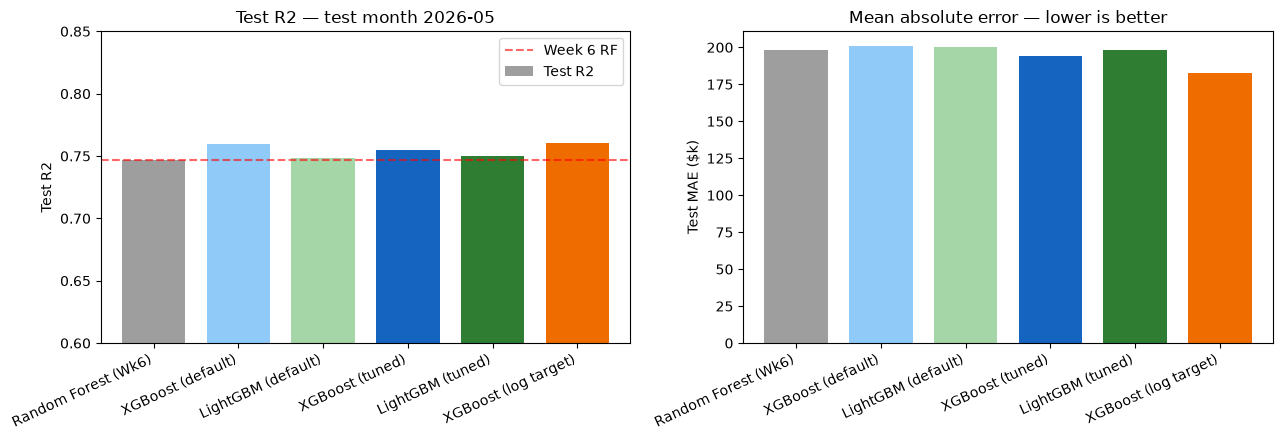

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
colors = ["#9E9E9E", "#90CAF9", "#A5D6A7", "#1565C0", "#2E7D32", "#EF6C00"]

summary["Test R2"].plot(kind="bar", ax=axes[0], color=colors, width=0.75)
axes[0].axhline(summary.loc["Random Forest (Wk6)", "Test R2"], color="red", ls="--", alpha=0.6,
                label="Week 6 RF")
axes[0].set_ylabel("Test R2"); axes[0].set_title(f"Test R2 — test month {split['test_month']}")
axes[0].set_ylim(0.6, max(0.85, summary["Test R2"].max() + 0.03))
axes[0].set_xticklabels(summary.index, rotation=25, ha="right"); axes[0].legend()

(summary["MAE"] / 1000).plot(kind="bar", ax=axes[1], color=colors, width=0.75)
axes[1].set_ylabel("Test MAE ($k)"); axes[1].set_title("Mean absolute error — lower is better")
axes[1].set_xticklabels(summary.index, rotation=25, ha="right")
plt.tight_layout(); plt.show()

## 7. Re-sweep the training window `X` for the winning model

Week 4 picked `X = 13` using a *linear* model. Boosting has different appetite for data (more history
helps it, but old months are staler), so the window is worth re-checking. Each `X` gets its own
train-only encoders — no leakage across the sweep.

Winner so far: XGBoost (log target)


  X= 3  rows= 31,622  test R2=0.7297  MAE=$203,641


  X= 6  rows= 59,169  test R2=0.7458  MAE=$195,226


  X= 9  rows= 93,978  test R2=0.7468  MAE=$190,861


  X=13  rows=141,277  test R2=0.7607  MAE=$182,806


  X=18  rows=190,025  test R2=0.7644  MAE=$180,388


  X=24  rows=265,202  test R2=0.7794  MAE=$176,423


  X=28  rows=307,335  test R2=0.7703  MAE=$176,757


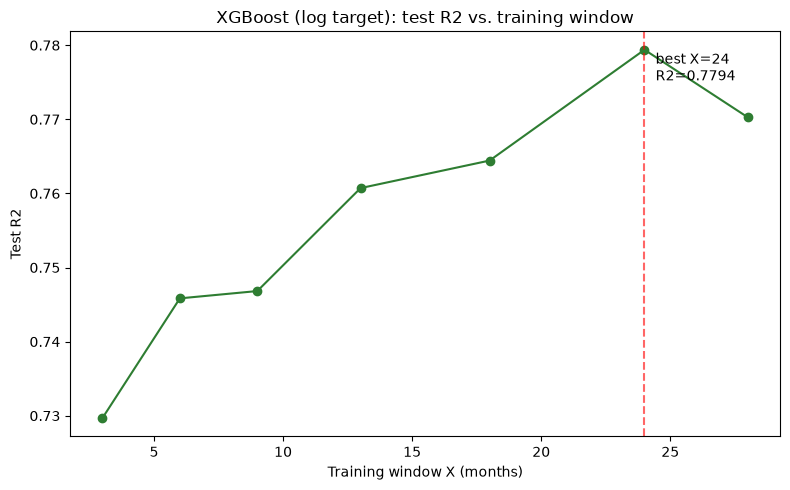


Best window for XGBoost (log target): X=24 (test R2=0.7794) vs. X=13 from Week 4 (0.7607)


In [11]:
winner_name = summary["Test R2"].idxmax()
print("Winner so far:", winner_name)
use_log = "log target" in winner_name

sweep_rows = []
for X in [3, 6, 9, 13, 18, 24, 28]:
    s = build_split(X, val_months=0)
    m = make_best()
    yt = np.log(s["y_train"]) if use_log else s["y_train"]
    m.fit(s["X_train"], yt)
    p = np.exp(m.predict(s["X_test"])) if use_log else m.predict(s["X_test"])
    sweep_rows.append({"X": X, "train_rows": len(s["y_train"]), **evaluate(s["y_test"], p)})
    print(f"  X={X:>2}  rows={len(s['y_train']):>7,}  test R2={sweep_rows[-1]['R2']:.4f}  "
          f"MAE=${sweep_rows[-1]['MAE']:,.0f}")

window_sweep = pd.DataFrame(sweep_rows)
best_row = window_sweep.loc[window_sweep["R2"].idxmax()]

fig, ax = plt.subplots()
ax.plot(window_sweep["X"], window_sweep["R2"], marker="o", color="#2E7D32")
ax.axvline(best_row["X"], color="red", ls="--", alpha=0.6)
ax.set_xlabel("Training window X (months)"); ax.set_ylabel("Test R2")
ax.set_title(f"{winner_name}: test R2 vs. training window")
ax.annotate(f"best X={int(best_row['X'])}\nR2={best_row['R2']:.4f}",
            xy=(best_row["X"], best_row["R2"]), xytext=(8, -22), textcoords="offset points")
plt.tight_layout(); plt.show()

print(f"\nBest window for {winner_name}: X={int(best_row['X'])} (test R2={best_row['R2']:.4f}) "
      f"vs. X=13 from Week 4 ({window_sweep.set_index('X').loc[13, 'R2']:.4f})")

## 8. What is the model using?

Gain-based importance for the winning model, plus the train/test gap as an overfitting read-out.

FINAL MODEL: XGBoost (log target) @ X=24
  test R2   : 0.7794   (train R2 0.9641)
  test RMSE : $660,652
  test MAE  : $176,423
  MdAPE     : 7.78%


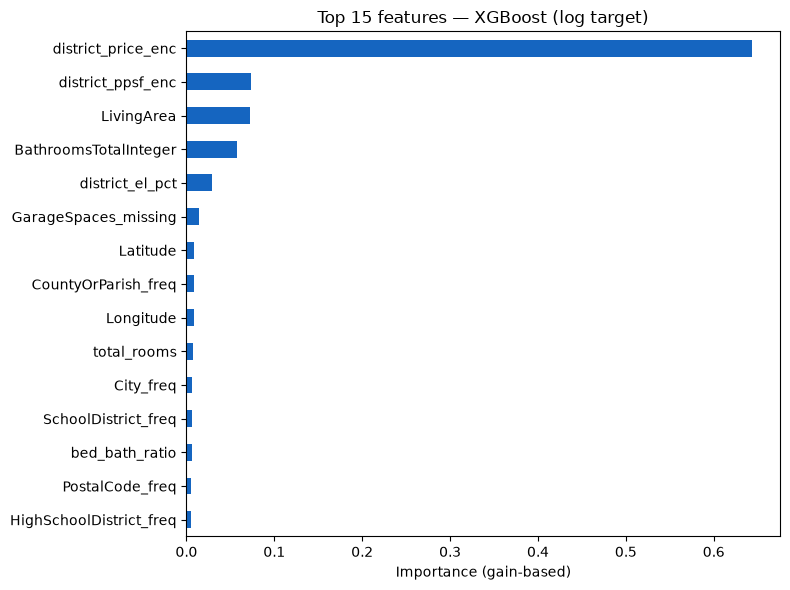

district_price_enc         0.6432
district_ppsf_enc          0.0739
LivingArea                 0.0718
BathroomsTotalInteger      0.0579
district_el_pct            0.0296
GarageSpaces_missing       0.0144
Latitude                   0.0089
CountyOrParish_freq        0.0088
Longitude                  0.0087
total_rooms                0.0069
City_freq                  0.0062
SchoolDistrict_freq        0.0061
bed_bath_ratio             0.0061
PostalCode_freq            0.0052
HighSchoolDistrict_freq    0.0052


In [12]:
FINAL_X = int(best_row["X"])
final_split = build_split(FINAL_X, val_months=0)
final_model = make_best()
final_y = np.log(final_split["y_train"]) if use_log else final_split["y_train"]
final_model.fit(final_split["X_train"], final_y)

final_pred = final_model.predict(final_split["X_test"])
if use_log:
    final_pred = np.exp(final_pred)
final_metrics = evaluate(final_split["y_test"], final_pred)
train_pred = final_model.predict(final_split["X_train"])
if use_log:
    train_pred = np.exp(train_pred)

print(f"FINAL MODEL: {winner_name} @ X={FINAL_X}")
print(f"  test R2   : {final_metrics['R2']:.4f}   (train R2 {r2_score(final_split['y_train'], train_pred):.4f})")
print(f"  test RMSE : ${final_metrics['RMSE']:,.0f}")
print(f"  test MAE  : ${final_metrics['MAE']:,.0f}")
print(f"  MdAPE     : {np.median(np.abs(final_pred - final_split['y_test']) / final_split['y_test']) * 100:.2f}%")

booster_imp = pd.Series(final_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 6))
booster_imp.head(15).iloc[::-1].plot(kind="barh", ax=ax, color="#1565C0")
ax.set_xlabel("Importance (gain-based)"); ax.set_title(f"Top 15 features — {winner_name}")
plt.tight_layout(); plt.show()
print(booster_imp.head(15).round(4).to_string())

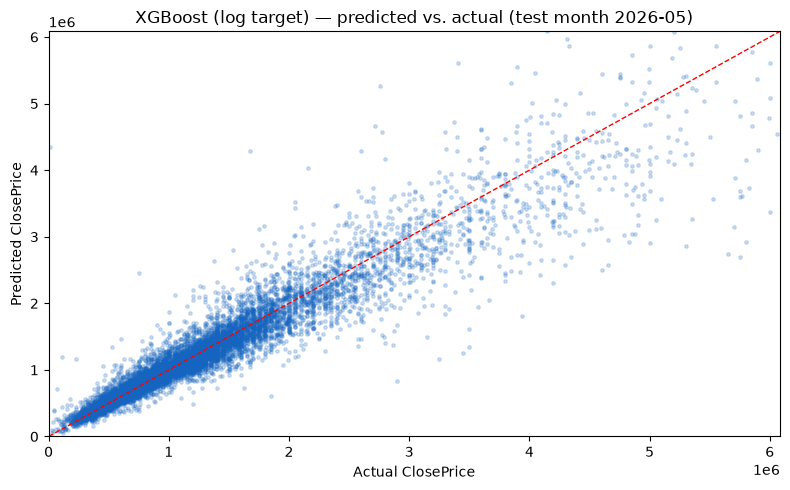

In [13]:
fig, ax = plt.subplots()
ax.scatter(final_split["y_test"], final_pred, s=6, alpha=0.2, color="#1565C0")
lims = [0, float(final_split["y_test"].quantile(0.99))]
ax.plot(lims, lims, "r--", lw=1)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Actual ClosePrice"); ax.set_ylabel("Predicted ClosePrice")
ax.set_title(f"{winner_name} — predicted vs. actual (test month {final_split['test_month']})")
plt.tight_layout(); plt.show()

## 9. Save the model bundle

Weeks 8-9 need more than the fitted estimator — they need everything required to turn a raw property
description into a prediction. The bundle carries the estimator, the feature order, the train-only
encoders, and the metadata describing how it was trained.

In [14]:
import os
os.makedirs("models", exist_ok=True)

bundle = {
    "model": final_model,
    "model_name": winner_name,
    "log_target": use_log,
    "feature_cols": FEATURE_COLS,
    "numeric_cols": NUMERIC,
    "categorical_cols": CATEGORICAL,
    "encoders": final_split["enc"],
    "train_window_X": FINAL_X,
    "train_months": final_split["train_months"],
    "test_month": final_split["test_month"],
    "test_metrics": final_metrics,
    "sklearn_feature_order": FEATURE_COLS,
    "created_from": "06_advanced_models.ipynb (Week 7)",
}
joblib.dump(bundle, "models/best_model.joblib", compress=3)
size_mb = os.path.getsize("models/best_model.joblib") / 1e6
print(f"Saved models/best_model.joblib ({size_mb:.1f} MB)")

summary.round(4).to_csv("data/processed/advanced_model_results.csv")
window_sweep.to_csv("data/processed/advanced_window_sweep.csv", index=False)
xgb_tuning.to_csv("data/processed/xgb_tuning.csv", index=False)
lgb_tuning.to_csv("data/processed/lgb_tuning.csv", index=False)
print("Saved tuning + results tables to data/processed/")

print(f"\n=== WEEK 7 ADVANCED MODELS (test month {final_split['test_month']}) ===")
for name in summary.index:
    r = summary.loc[name]
    print(f"{name:26s} test R2={r['Test R2']:.4f}  RMSE=${r['RMSE']:,.0f}  MAE=${r['MAE']:,.0f}")
print(f"\nShipped: {winner_name} @ X={FINAL_X}  ->  test R2 {final_metrics['R2']:.4f}, "
      f"MAE ${final_metrics['MAE']:,.0f}")
print(f"Week 6 Random Forest was R2 {summary.loc['Random Forest (Wk6)', 'Test R2']:.4f} "
      f"-> improvement {final_metrics['R2'] - summary.loc['Random Forest (Wk6)', 'Test R2']:+.4f}")

Saved models/best_model.joblib (6.2 MB)
Saved tuning + results tables to data/processed/

=== WEEK 7 ADVANCED MODELS (test month 2026-05) ===
Random Forest (Wk6)        test R2=0.7466  RMSE=$708,006  MAE=$198,286
XGBoost (default)          test R2=0.7593  RMSE=$690,027  MAE=$200,772
LightGBM (default)         test R2=0.7486  RMSE=$705,184  MAE=$200,426
XGBoost (tuned)            test R2=0.7552  RMSE=$695,949  MAE=$193,892
LightGBM (tuned)           test R2=0.7504  RMSE=$702,733  MAE=$198,322
XGBoost (log target)       test R2=0.7607  RMSE=$688,044  MAE=$182,806

Shipped: XGBoost (log target) @ X=24  ->  test R2 0.7794, MAE $176,423
Week 6 Random Forest was R2 0.7466 -> improvement +0.0328
